# Baseline Models: Ridge, Lasso, LightGBM, CatBoost

Бейзлайн-сравнение классических ML-моделей регрессии на 5-минутных барах.  
Горизонт прогнозирования — 12 баров (1 час). Метрики аналогичны основной модели 1D-CNN из `models.ipynb`.

**Подбор гиперпараметров:** Optuna (TPE sampler) + TimeSeriesSplit (без утечки из будущего)  
**Источник методологии:** [mlgu.ru/5446](https://mlgu.ru/5446/)  
**Модели:** Ridge, Lasso, LightGBM, CatBoost  
**Данные:** 5-минутные свечи MOEX (2020–2025)

In [38]:
# !pip install optuna lightgbm catboost

import numpy as np
import pandas as pd
from pathlib import Path
import time

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

## 1. Параметры

In [39]:
# ══════════════════════════════════════════════
# ПАРАМЕТРЫ СТРАТЕГИИ
# ══════════════════════════════════════════════
HORIZON        = 12           # горизонт прогноза (баров)
TRAIN_YEARS    = 4            # лет на обучение
TEST_YEARS     = 2            # лет на тест
Z_THRESHOLD    = 1.0        # порог для входа в позицию (0.3% - с учетом комиссий и проскальзывания)
COMMISSION     = 0.0003       # 0.03 % round-trip комиссия брокера/биржи
SLIPPAGE       = 0.0002       # 0.02 % проскальзывание (для ликвидных бумаг)
SHORT_RATE     = 0.10         # ~10% годовых за заем акций для шорта
BARS_PER_YEAR  = 252 * 78     # 5-минутные бары в году

# ══════════════════════════════════════════════
# ПАРАМЕТРЫ OPTUNA
# ══════════════════════════════════════════════
N_OPTUNA_TRIALS = 50          # кол-во итераций подбора
N_CV_SPLITS     = 3           # кол-во фолдов TimeSeriesSplit
OPTUNA_SEED     = 42          # для воспроизводимости
OPTUNA_SUBSAMPLE = 5          # брать каждый 5-й бар для ускорения Optuna

# ══════════════════════════════════════════════
# ДАННЫЕ
# ══════════════════════════════════════════════
DATA_DIR       = Path("data")
START_DATE     = "2020-01-01"
END_DATE       = "2026-01-01"

TICKERS = ['SBER', 'MGNT', 'VTBR', 'TATN', 'LKOH', 'YDEX', 'GLDRUB_TOM']

## 2. Утилиты: очистка данных

In [40]:
def filter_trading_hours(df: pd.DataFrame) -> pd.DataFrame:
    """
    Оставляет только основную и вечернюю сессию МОЕХ (10:00 - 23:50).
    Удаляет выходные и праздничные дни. НЕ заполняет ночные промежутки ffill!
    """
    df = df.copy()
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    elif not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame должен иметь колонку 'DateTime' или DatetimeIndex")

    # Оставляем только будни (0=Пн, 4=Пт)
    df = df[df.index.dayofweek < 5]
    
    # Оставляем основную + вечернюю сессию (с 10:00 до 23:50)
    df = df.between_time('10:00', '23:50')
    
    return df.reset_index()


def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Базовая очистка рыночных данных: замена нулевых цен на NaN + ffill/bfill.
    """
    df = df.copy()
    if 'DateTime' in df.columns:
        df = df.set_index('DateTime').sort_index()

    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        if col in df.columns:
            df[col] = df[col].replace(0, pd.NA)

    df[cols_to_fix] = df[cols_to_fix].ffill().bfill()
    if 'Volume' in df.columns:
        df['Volume'] = df['Volume'].fillna(0)

    return df.reset_index() if 'DateTime' not in df.columns else df

## 3. Feature Engineering

In [41]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Расширенный Feature Engineering:
    - Циклическое время (час, день недели)
    - Микроструктурные фичи (тело/тень свечи, Z-score объема)
    - Волатильность (для нормализации таргета)
    """
    df = df.copy()
    close  = df["Close"]
    volume = df["Volume"]
    high = df["High"]
    low = df["Low"]
    open_ = df["Open"]

    # Возвраты
    df["return"] = close.pct_change()

    # Лагированные возвраты и объемы
    for lag in [1, 2, 3, 5, 10, 20]:
        df.loc[:, f"ret_lag_{lag}"] = df["return"].shift(lag)
        df.loc[:, f"vol_lag_{lag}"] = volume.shift(lag)

    # Волатильность
    df.loc[:, "volatility"] = df["return"].rolling(20).std()

    # RSI
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    rs    = gain.rolling(14).mean() / loss.rolling(14).mean()
    df.loc[:, "RSI"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    df.loc[:, "MACD"] = ema12 - ema26

    # === НОВЫЕ ФИЧИ ===
    
    # 1. Циклическое кодирование времени (важно для внутридневных паттернов)
    if 'DateTime' in df.columns:
        dt = pd.to_datetime(df['DateTime'])
        hour = dt.dt.hour + dt.dt.minute / 60.0
        df.loc[:, 'hour_sin'] = np.sin(2 * np.pi * hour / 24)
        df.loc[:, 'hour_cos'] = np.cos(2 * np.pi * hour / 24)
        
        dow = dt.dt.dayofweek
        df.loc[:, 'dow_sin'] = np.sin(2 * np.pi * dow / 5)
        df.loc[:, 'dow_cos'] = np.cos(2 * np.pi * dow / 5)

    # 2. Микроструктура свечи
    candle_range = high - low
    df.loc[:, 'body_ratio'] = (close - open_) / candle_range.replace(0, np.nan)
    df.loc[:, 'upper_shadow'] = (high - pd.concat([close, open_], axis=1).max(axis=1)) / candle_range.replace(0, np.nan)
    df.loc[:, 'lower_shadow'] = (pd.concat([close, open_], axis=1).min(axis=1) - low) / candle_range.replace(0, np.nan)

    # 3. Z-Score объема (аномалии объема)
    vol_mean = volume.rolling(20).mean()
    vol_std = volume.rolling(20).std()
    df.loc[:, 'volume_zscore'] = (volume - vol_mean) / vol_std.replace(0, np.nan)

    df = df.replace([np.inf, -np.inf], np.nan)
    return df.dropna()

## 4. Optuna: пространства поиска гиперпараметров

In [42]:
def create_model_from_trial(trial: optuna.Trial, model_name: str):
    """
    Для каждого trial Optuna сэмплирует гиперпараметры
    и возвращает (модель, uses_scaled_data: bool).
    """

    if model_name == "Ridge":
        alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
        return Ridge(alpha=alpha), True

    elif model_name == "Lasso":
        alpha = trial.suggest_float("alpha", 1e-6, 1e-1, log=True)
        return Lasso(alpha=alpha, max_iter=5000), True

    elif model_name == "LightGBM":
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 500, 4000, step=500),
            "learning_rate":     trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
            "max_depth":         trial.suggest_int("max_depth", 2, 6),
            "num_leaves":        trial.suggest_int("num_leaves", 4, 31),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.2, 0.8),
            "subsample":         trial.suggest_float("subsample", 0.2, 0.8),
            "reg_alpha":         trial.suggest_float("reg_alpha", 0.01, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 0.01, 10.0, log=True),
            "random_state":      42,
            "verbosity":         -1,
        }
        return LGBMRegressor(**params), False

    elif model_name == "CatBoost":
        params = {
            "iterations":          trial.suggest_int("iterations", 500, 4000, step=500),
            "learning_rate":       trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
            "depth":               trial.suggest_int("depth", 2, 6),
            "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "random_strength":     trial.suggest_float("random_strength", 0.01, 10.0, log=True),
            "verbose":             0,
            "random_state":        42,
        }
        return CatBoostRegressor(**params), False

    else:
        raise ValueError(f"Unknown model: {model_name}")

## 5. Optuna objective + подбор

In [43]:
def optimize_model(model_name: str,
                   X_train: np.ndarray, y_train: np.ndarray,
                   X_train_scaled: np.ndarray,
                   n_trials: int = N_OPTUNA_TRIALS,
                   n_splits: int = N_CV_SPLITS) -> tuple:
    """
    Подбирает гиперпараметры через Optuna + TimeSeriesSplit(gap=HORIZON).
    Минимизирует 1 - Directional Accuracy (максимизирует долю верно угаданных направлений).
    Это решает проблему "нулевых предсказаний" бустингов.
    """
    # GAP = HORIZON защищает от утечки из будущего
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=HORIZON)

    def objective(trial):
        model, uses_scaled = create_model_from_trial(trial, model_name)
        X = X_train_scaled if uses_scaled else X_train

        dir_acc_scores = []
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            # Создаем свежую модель с теми же параметрами для каждого фолда
            if model_name == "Ridge":
                model_cv = Ridge(alpha=trial.params["alpha"])
            elif model_name == "Lasso":
                model_cv = Lasso(alpha=trial.params["alpha"], max_iter=5000)
            elif model_name == "LightGBM":
                p = trial.params
                p.update({"random_state": 42, "verbosity": -1})
                model_cv = LGBMRegressor(**p)
            elif model_name == "CatBoost":
                p = trial.params
                p.update({"verbose": 0, "random_state": 42})
                model_cv = CatBoostRegressor(**p)

            model_cv.fit(X_tr, y_tr)
            y_pred = model_cv.predict(X_val)

            # Считаем Directional Accuracy (доля совпадений знаков)
            dir_acc = np.mean(np.sign(y_val) == np.sign(y_pred))
            dir_acc_scores.append(dir_acc)

        # Возвращаем 1 - средняя точность направления (так как Optuna минимизирует)
        return 1.0 - np.mean(dir_acc_scores)

    sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    return study.best_params, study.best_value

In [44]:
def build_best_model(model_name: str, best_params: dict):
    """
    Создаёт финальную модель с лучшими гиперпараметрами.
    """
    if model_name == "Ridge":
        return Ridge(**best_params), True
    elif model_name == "Lasso":
        return Lasso(**best_params, max_iter=5000), True
    elif model_name == "LightGBM":
        return LGBMRegressor(**best_params, random_state=42, verbosity=-1), False
    elif model_name == "CatBoost":
        return CatBoostRegressor(**best_params, verbose=0, random_state=42), False
    else:
        raise ValueError(f"Unknown model: {model_name}")

## 6. Бэктест + метрики

In [45]:
def run_backtest(z_pred: np.ndarray, prices: np.ndarray, vol_test: np.ndarray,
                 horizon: int = HORIZON,
                 z_threshold: float = Z_THRESHOLD,
                 commission: float = COMMISSION,
                 slippage: float = SLIPPAGE,
                 short_rate_annual: float = SHORT_RATE) -> dict:
    """
    Бэктест с адаптивным Z-порогом.
    z_pred: предсказания модели (в единицах стандартного отклонения)
    vol_test: историческая волатильность на тесте
    """
    trades = []
    equity = [1.0]
    position_open = False
    entry_price = 0.0
    entry_idx = 0
    is_short = False

    short_cost_per_bar = (short_rate_annual / BARS_PER_YEAR)

    for i in range(len(z_pred)):
        z_score = z_pred[i]
        price = prices[i]
        current_vol = vol_test[i]

        if position_open and (i >= entry_idx + horizon or i == len(z_pred) - 1):
            exit_price = price * (1 - slippage) if is_short else price * (1 + slippage)
            
            if is_short:
                ret = (entry_price - exit_price) / entry_price
                ret -= commission + (short_cost_per_bar * (i - entry_idx))
            else:
                ret = (exit_price - entry_price) / entry_price - commission

            equity.append(equity[-1] * (1 + ret))
            trades.append(ret)
            position_open = False

        if not position_open:
            # Используем Z-score для входа вместо фиксированного процента
            if z_score > z_threshold:
                position_open = True
                is_short = False
                entry_price = price * (1 + slippage) * (1 + commission)
                entry_idx = i
            elif z_score < -z_threshold:
                position_open = True
                is_short = True
                entry_price = price * (1 - slippage) * (1 - commission)
                entry_idx = i
        else:
            equity.append(equity[-1])

    equity = np.array(equity)
    returns_eq = np.diff(equity) / equity[:-1]

    if trades:
        pnls = np.array(trades)
        n = len(pnls)
        win_rate      = (pnls > 0).mean() * 100
        total_return  = (equity[-1] - 1) * 100
        avg_trade     = pnls.mean() * 100
        gross_profit  = pnls[pnls > 0].sum()
        gross_loss    = abs(pnls[pnls < 0].sum())
        profit_factor = gross_profit / gross_loss if gross_loss != 0 else float('inf')
        avg_win  = pnls[pnls > 0].mean() if (pnls > 0).any() else 0
        avg_loss_val = abs(pnls[pnls < 0].mean()) if (pnls < 0).any() else 0
        avg_rr   = avg_win / avg_loss_val if avg_loss_val != 0 else float('inf')
        sharpe = (np.mean(returns_eq) / np.std(returns_eq) * np.sqrt(BARS_PER_YEAR)
                  if np.std(returns_eq) > 0 else 0)
        se  = pnls.std() / np.sqrt(n) if n > 1 else 0
        mde = 2.8 * se * 100
        stat_sig = abs(pnls.mean() * 100) > mde
    else:
        n = 0
        win_rate = total_return = avg_trade = 0
        profit_factor = avg_rr = sharpe = mde = 0
        stat_sig = False

    return {
        "n_trades": n, "win_rate": win_rate, "total_return": total_return,
        "avg_trade": avg_trade, "profit_factor": profit_factor, "avg_rr": avg_rr,
        "sharpe": sharpe, "mde": mde, "stat_sig": stat_sig, "equity": equity,
    }

In [46]:
def print_report(name: str, ticker: str, mae: float, rmse: float,
                 metrics: dict, test_days: int, best_params: dict,
                 cv_score: float, tune_time: float) -> None:
    """Форматированный вывод результатов."""
    print("\n══════════════════════════════════════════════════════════════════════")
    print(f"ИТОГО ПО СТРАТЕГИИ -> {name} | {ticker} (горизонт {HORIZON} баров)")
    print("══════════════════════════════════════════════════════════════════════")
    print(f"Лучшие гиперпараметры (Optuna, {N_OPTUNA_TRIALS} trials):")
    for k, v in best_params.items():
        val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
        print(f"  {k:25s} = {val_str}")
    print(f"  CV Score (1 - Dir.Acc): {cv_score:.6f}")
    print(f"  Время подбора:            {tune_time:.1f} сек")
    print("----------------------------------------------------------------------")
    print(f"Test MAE / RMSE:       {mae:.6f} / {rmse:.6f}")
    print(f"Всего сделок:          {metrics['n_trades']}")
    print(f"Win Rate:              {metrics['win_rate']:.1f} %")
    print(f"Общая доходность:      {metrics['total_return']:.1f} %")
    print(f"Средняя сделка:        {metrics['avg_trade']:.4f} %")
    print(f"Profit Factor:         {metrics['profit_factor']:.2f}")
    print(f"Average RR Ratio:      {metrics['avg_rr']:.2f}")
    print(f"Sharpe Ratio:          {metrics['sharpe']:.2f}")
    print(f"MDE (мин. значимый эффект): {metrics['mde']:.2f} %")
    print(f"Статистическая значимость: {'ДА' if metrics['stat_sig'] else 'НЕТ (шум)'}")
    print("----------------------------------------------------------------------")
    print(f"Период теста:          {test_days} дней = {round(test_days / 30.4375, 1)} мес.")
    print(f"Средний holding period: {HORIZON} баров (фиксированный)")
    print(f"Комиссия + Slippage:   {COMMISSION*100:.2f}% + {SLIPPAGE*100:.2f}%")
    print("══════════════════════════════════════════════════════════════════════")

## 7. Основной пайплайн: один тикер

In [47]:
MODEL_NAMES = ["Ridge", "Lasso", "LightGBM", "CatBoost"]

def run_baseline_for_ticker(ticker: str, verbose: bool = True) -> list:
    fpath = DATA_DIR / f"{ticker}_5min.parquet"
    if not fpath.exists():
        print(f"WARNING: Файл {fpath} не найден — пропускаю {ticker}")
        return []

    df = pd.read_parquet(fpath)
    df = df[(df['DateTime'] >= START_DATE) & (df['DateTime'] < END_DATE)]
    df = filter_trading_hours(df)
    df = clean_market_data(df)

    if 'DateTime' not in df.columns:
        df = df.reset_index()
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.sort_values("DateTime").reset_index(drop=True)

    if verbose:
        print(f"\n{'#'*70}")
        print(f"# ТИКЕР: {ticker}  |  строк: {len(df):,}")
        print(f"{'#'*70}")

    df = add_features(df)
    df["rolling_vol"] = df["return"].rolling(20).std().shift(1)
    df["raw_target"] = df["Close"].pct_change(HORIZON).shift(-HORIZON)
    df["target"] = df["raw_target"] / df["rolling_vol"].replace(0, np.nan)
    df = df.dropna()

    start_date = df["DateTime"].min()
    train_end  = start_date + pd.DateOffset(years=TRAIN_YEARS)
    test_end   = train_end  + pd.DateOffset(years=TEST_YEARS)

    train_df = df[df["DateTime"] < train_end].copy()
    test_df  = df[(df["DateTime"] >= train_end) & (df["DateTime"] < test_end)].copy()

    if len(train_df) < 1000 or len(test_df) < 100:
        print(f"WARNING: Недостаточно данных для {ticker}")
        return []

    test_days = (test_df['DateTime'].max() - test_df['DateTime'].min()).days

    feature_cols = [c for c in df.columns if c not in ["DateTime", "target", "raw_target", "rolling_vol"]]

    X_train_raw = train_df[feature_cols].values
    y_train_arr = train_df["target"].values
    X_test_raw  = test_df[feature_cols].values
    y_test_arr  = test_df["target"].values
    prices_test = test_df["Close"].values
    vol_test = test_df["rolling_vol"].values 

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    sub_idx = np.arange(0, len(X_train_raw), OPTUNA_SUBSAMPLE)
    X_train_sub = X_train_raw[sub_idx]
    y_train_sub = y_train_arr[sub_idx]
    X_train_scaled_sub = X_train_scaled[sub_idx]

    results_rows = []
    model_predictions = {} # Сохраняем предсказания для ансамбля

    for model_name in MODEL_NAMES:
        if verbose:
            print(f"\n{'='*20} {model_name}: Optuna {'='*20}")

        t0 = time.time()
        best_params, cv_score = optimize_model(
            model_name, X_train_sub, y_train_sub, X_train_scaled_sub
        )
        tune_time = time.time() - t0

        final_model, uses_scaled = build_best_model(model_name, best_params)
        X_fit  = X_train_scaled if uses_scaled else X_train_raw
        X_pred = X_test_scaled  if uses_scaled else X_test_raw

        final_model.fit(X_fit, y_train_arr)
        y_pred_norm = final_model.predict(X_pred)
        
        model_predictions[model_name] = y_pred_norm

        # Восстанавливаем предсказания в проценты только для подсчета MAE/RMSE
        y_pred_raw = y_pred_norm * vol_test
        mae  = mean_absolute_error(y_test_arr * vol_test, y_pred_raw)
        rmse = np.sqrt(mean_squared_error(y_test_arr * vol_test, y_pred_raw))

        # Передаем Z-оценки в бэктест!
        metrics = run_backtest(y_pred_norm, prices_test, vol_test)

        if verbose:
            print_report(model_name, ticker, mae, rmse, metrics, test_days, best_params, cv_score, tune_time)

        results_rows.append({
            "Ticker": ticker, "Model": model_name, "MAE": mae, "RMSE": rmse,
            "Trades": metrics["n_trades"], "Win Rate %": round(metrics["win_rate"], 1),
            "Total Return %": round(metrics["total_return"], 2), "Avg Trade %": round(metrics["avg_trade"], 4),
            "Profit Factor": round(metrics["profit_factor"], 2), "Sharpe": round(metrics["sharpe"], 2),
            "Stat Sig": metrics["stat_sig"]
        })

    # === БОНУС: ПРОСТОЙ АНСЕМБЛЬ (Голосование Ridge + LightGBM) ===
    if verbose:
        print(f"\n{'='*20} ENSEMBLE (Ridge + LightGBM Voting) {'='*20}")
    
    ridge_z = model_predictions.get("Ridge")
    lgbm_z = model_predictions.get("LightGBM")
    
    if ridge_z is not None and lgbm_z is not None:
        # Усредняем Z-оценки
        ensemble_z = (ridge_z + lgbm_z) / 2.0
        metrics_ens = run_backtest(ensemble_z, prices_test, vol_test)
        
        if verbose:
            print(f"  Trades: {metrics_ens['n_trades']} | Win Rate: {metrics_ens['win_rate']:.1f}% | "
                  f"Return: {metrics_ens['total_return']:.1f}% | Sharpe: {metrics_ens['sharpe']:.2f}")
        
        results_rows.append({
            "Ticker": ticker, "Model": "Ensemble_Ridge_LGBM", "MAE": None, "RMSE": None,
            "Trades": metrics_ens["n_trades"], "Win Rate %": round(metrics_ens["win_rate"], 1),
            "Total Return %": round(metrics_ens["total_return"], 2), "Avg Trade %": round(metrics_ens["avg_trade"], 4),
            "Profit Factor": round(metrics_ens["profit_factor"], 2), "Sharpe": round(metrics_ens["sharpe"], 2),
            "Stat Sig": metrics_ens["stat_sig"]
        })

    return results_rows

## 8. Запуск по всем тикерам

In [48]:
all_results = []

for ticker in TICKERS:
    ticker_res = run_baseline_for_ticker(ticker, verbose=True)
    all_results.extend(ticker_res)

# Сводная таблица
summary_df = pd.DataFrame(all_results)
cols_to_show = ["Ticker", "Model", "Trades", "Win Rate %", "Total Return %", 
                "Avg Trade %", "Profit Factor", "Sharpe", "Stat Sig"]

print("\n\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ БЕЙЗЛАЙНОВ")
print("="*80)
display(summary_df[cols_to_show])


######################################################################
# ТИКЕР: SBER  |  строк: 179,324
######################################################################

==================== Ridge: Optuna ====================

══════════════════════════════════════════════════════════════════════
ИТОГО ПО СТРАТЕГИИ -> Ridge | SBER (горизонт 12 баров)
══════════════════════════════════════════════════════════════════════
Лучшие гиперпараметры (Optuna, 50 trials):
  alpha                     = 0.001054
  CV Score (1 - Dir.Acc): 0.496847
  Время подбора:            0.3 сек
----------------------------------------------------------------------
Test MAE / RMSE:       0.002381 / 0.004211
Всего сделок:          111
Win Rate:              55.9 %
Общая доходность:      7.2 %
Средняя сделка:        0.0655 %
Profit Factor:         1.29
Average RR Ratio:      1.02
Sharpe Ratio:          3.38
MDE (мин. значимый эффект): 0.21 %
Статистическая значимость: НЕТ (шум)
----------------------------

,Ticker,Model,Trades,Win Rate %,Total Return %,Avg Trade %,Profit Factor,Sharpe,Stat Sig
0,SBER,Ridge,111,55.9,7.18,0.0655,1.29,3.38,False
1,SBER,Lasso,0,0.0,0.00,0.0000,0.00,0.00,False
2,SBER,LightGBM,305,40.3,-2.02,-0.0043,0.98,-0.25,False
3,SBER,CatBoost,295,51.9,14.45,0.0494,1.23,2.31,False
4,SBER,Ensemble_Ridge_LGBM,287,40.4,2.59,0.0112,1.06,0.67,False
5,MGNT,Ridge,1,0.0,-0.94,-0.9415,0.00,-42.27,True
6,MGNT,Lasso,0,0.0,0.00,0.0000,0.00,0.00,False
7,MGNT,LightGBM,1972,43.3,-65.75,-0.0526,0.75,-3.57,True
8,MGNT,CatBoost,1876,42.6,-62.63,-0.0506,0.76,-3.38,True
9,MGNT,Ensemble_Ridge_LGBM,1545,43.8,-52.77,-0.0465,0.78,-2.97,True


## 9. Сводная таблица результатов

In [49]:
summary_df = pd.DataFrame(all_results)

if not summary_df.empty:
    display_cols = [c for c in summary_df.columns if c != 'Best Params']

    print("\n" + "=" * 100)
    print("СВОДНАЯ ТАБЛИЦА BASELINE-МОДЕЛЕЙ (с подбором гиперпараметров)")
    print("=" * 100)
    display(summary_df[display_cols].style
            .format({
                'MAE':            '{:.6f}',
                'RMSE':           '{:.6f}',
                'CV_RMSE':        '{:.6f}',
                'Total Return %': '{:.2f}',
                'Avg Trade %':    '{:.4f}',
                'Profit Factor':  '{:.2f}',
                'Avg RR':         '{:.2f}',
                'Sharpe':         '{:.2f}',
                'MDE %':          '{:.2f}',
            })
            .background_gradient(subset=['Total Return %', 'Sharpe'], cmap='RdYlGn')
    )
else:
    print("Нет результатов — проверьте наличие parquet-файлов в data/")


СВОДНАЯ ТАБЛИЦА BASELINE-МОДЕЛЕЙ (с подбором гиперпараметров)


,Ticker,Model,MAE,RMSE,Trades,Win Rate %,Total Return %,Avg Trade %,Profit Factor,Sharpe,Stat Sig
0,SBER,Ridge,0.002381,0.004211,111,55.900000,7.18,0.0655,1.29,3.38,False
1,SBER,Lasso,0.002366,0.004188,0,0.000000,0.00,0.0000,0.00,0.00,False
2,SBER,LightGBM,0.002366,0.004189,305,40.300000,-2.02,-0.0043,0.98,-0.25,False
3,SBER,CatBoost,0.002358,0.004175,295,51.900000,14.45,0.0494,1.23,2.31,False
4,SBER,Ensemble_Ridge_LGBM,nan,nan,287,40.400000,2.59,0.0112,1.06,0.67,False
5,MGNT,Ridge,0.003639,0.005757,1,0.000000,-0.94,-0.9415,0.00,-42.27,True
6,MGNT,Lasso,0.003631,0.005749,0,0.000000,0.00,0.0000,0.00,0.00,False
7,MGNT,LightGBM,0.004848,0.007893,1972,43.300000,-65.75,-0.0526,0.75,-3.57,True
8,MGNT,CatBoost,0.006185,0.009382,1876,42.600000,-62.63,-0.0506,0.76,-3.38,True
9,MGNT,Ensemble_Ridge_LGBM,nan,nan,1545,43.800000,-52.77,-0.0465,0.78,-2.97,True


## 10. Лучшие гиперпараметры (для воспроизводимости)

In [50]:
if not summary_df.empty:
    print("\nЛучшие гиперпараметры по каждому (Ticker x Model):")
    print("-" * 80)
    for _, row in summary_df.iterrows():
        print(f"\n{row['Ticker']} | {row['Model']}  (RMSE: {row['RMSE']:.6f})")
        print(f"  {row['Best Params']}")


Лучшие гиперпараметры по каждому (Ticker x Model):
--------------------------------------------------------------------------------

SBER | Ridge  (RMSE: 0.004211)


KeyError: 'Best Params'

## 11. Агрегация: средние метрики по модели

In [51]:
if not summary_df.empty:
    agg_cols = ['Trades', 'Win Rate %', 'Total Return %', 'Avg Trade %',
                'Profit Factor', 'Avg RR', 'Sharpe', 'MDE %', 'Tune Time (s)']

    avg_by_model = summary_df.groupby('Model')[agg_cols].mean().round(3)
    avg_by_model = avg_by_model.sort_values('Sharpe', ascending=False)

    print("\n" + "=" * 100)
    print("СРЕДНИЕ МЕТРИКИ ПО МОДЕЛИ (across all tickers)")
    print("=" * 100)
    display(avg_by_model)

KeyError: "Columns not found: 'Tune Time (s)', 'MDE %', 'Avg RR'"

## 12. Визуализация: сравнительные bar-charts

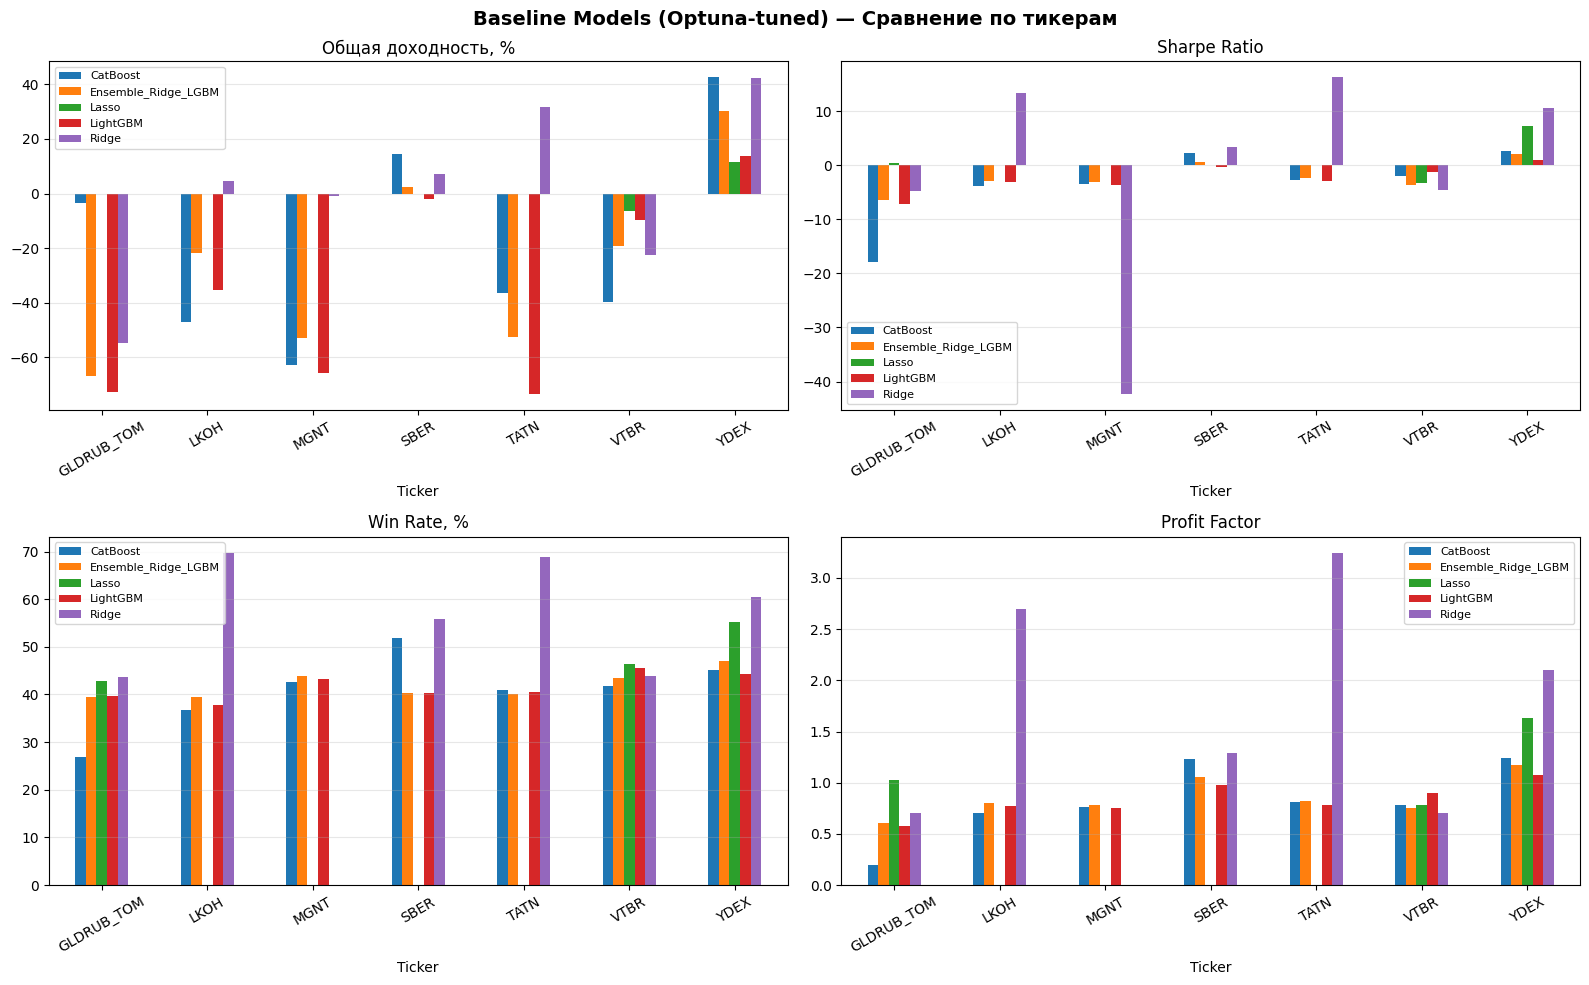

In [52]:
if not summary_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Baseline Models (Optuna-tuned) — Сравнение по тикерам',
                 fontsize=14, fontweight='bold')

    metrics_to_plot = [
        ('Total Return %', 'Общая доходность, %'),
        ('Sharpe',         'Sharpe Ratio'),
        ('Win Rate %',     'Win Rate, %'),
        ('Profit Factor',  'Profit Factor'),
    ]

    for ax, (col, title) in zip(axes.flat, metrics_to_plot):
        pivot = summary_df.pivot(index='Ticker', columns='Model', values=col)
        pivot.plot(kind='bar', ax=ax, rot=30)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 14. Экспорт результатов

In [53]:
if not summary_df.empty:
    out_path = DATA_DIR / "baseline_results_tuned.csv"
    summary_df.to_csv(out_path, index=False)
    print(f"Результаты сохранены: {out_path}")

Результаты сохранены: data/baseline_results_tuned.csv


Графики сохранены: baseline_comparison_academic.pdf и baseline_comparison_academic.png


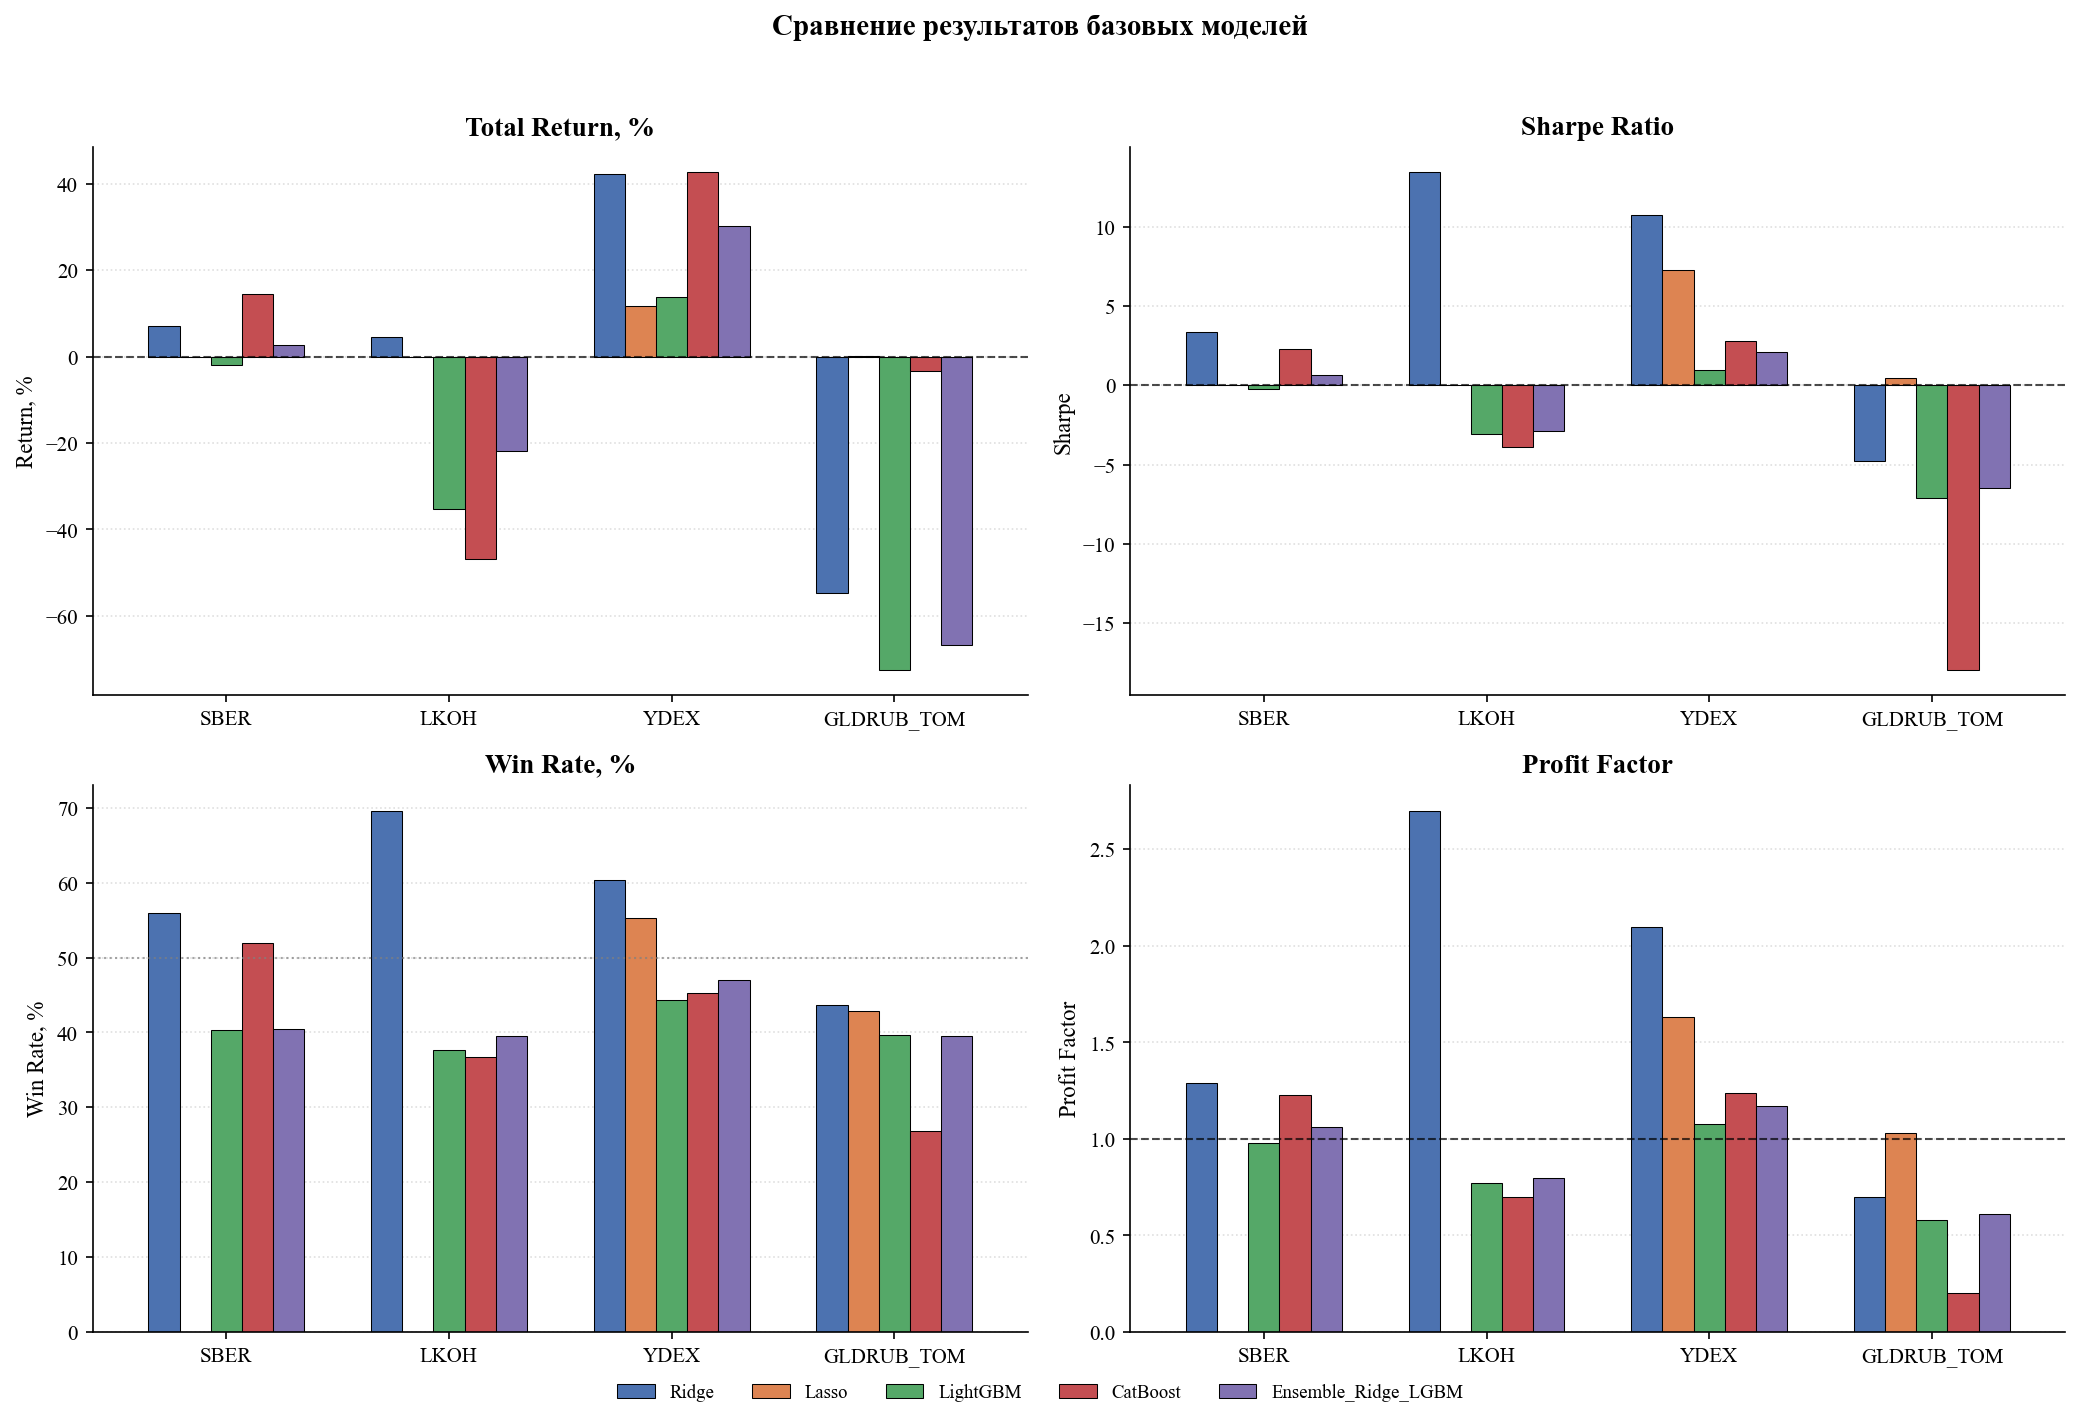

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# НАСТРОЙКИ СТИЛЯ (Академический формат)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Академическая палитра (приглушенные цвета, различимые при ч/б печати)
MODEL_COLORS = {
    'Ridge': '#4c72b0',                 # Приглушенный синий
    'Lasso': '#dd8452',                 # Приглушенный оранжевый
    'LightGBM': '#55a868',              # Приглушенный зеленый
    'CatBoost': '#c44e52',              # Приглушенный красный
    'Ensemble_Ridge_LGBM': '#8172b2'    # Приглушенный фиолетовый
}

# ==========================================
# ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ==========================================
# Укажите путь к вашему CSV файлу (3-й запуск, где есть Ensemble)
FILE_PATH = '/Users/alexsmirnov/Master_Degree/FQW/fqw_master_degree/baseline_results_tuned_3_launch.csv' 
df = pd.read_csv(FILE_PATH)

# Список тикеров в том порядке, в котором они должны идти на графике
TARGET_TICKERS = ['SBER', 'LKOH', 'YDEX', 'GLDRUB_TOM']
MODELS_ORDER = ['Ridge', 'Lasso', 'LightGBM', 'CatBoost', 'Ensemble_Ridge_LGBM']

# Фильтрация
df_filtered = df[df['Ticker'].isin(TARGET_TICKERS) & df['Model'].isin(MODELS_ORDER)].copy()

# Преобразование в категориальный тип для правильного порядка на графике
df_filtered['Ticker'] = pd.Categorical(df_filtered['Ticker'], categories=TARGET_TICKERS, ordered=True)
df_filtered['Model'] = pd.Categorical(df_filtered['Model'], categories=MODELS_ORDER, ordered=True)

# Сортировка
df_filtered = df_filtered.sort_values(['Ticker', 'Model'])

# ==========================================
# ФУНКЦИЯ ПОСТРОЕНИЯ ГРАФИКА
# ==========================================
def plot_metric(ax, data, y_col, title, ylabel, hline_val=None, hline_style='--', hline_color='black'):
    """Вспомогательная функция для отрисовки одного подграфика"""
    # Группировка данных
    pivot_df = data.pivot(index='Ticker', columns='Model', values=y_col)
    
    # Перестановка колонок в нужном порядке (только те, что есть в данных)
    cols_present = [m for m in MODELS_ORDER if m in pivot_df.columns]
    pivot_df = pivot_df[cols_present]
    
    # Цвета для присутствующих моделей
    colors = [MODEL_COLORS[m] for m in cols_present]
    
    # Построение столбчатой диаграммы
    pivot_df.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5, width=0.7)
    
    # Настройка осей
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('') # Убираем подпись оси X, она очевидна
    ax.tick_params(axis='x', rotation=0) # Подписи тикеров горизонтально
    
    # Горизонтальная линия (например, 0 для доходности)
    if hline_val is not None:
        ax.axhline(y=hline_val, color=hline_color, linestyle=hline_style, linewidth=1.0, alpha=0.7)
    
    # Убираем легенду с подграфиков (будет одна общая)
    ax.get_legend().remove()
    
    # Добавляем слабую сетку по Y для читаемости
    ax.yaxis.grid(True, linestyle=':', alpha=0.4)
    ax.set_axisbelow(True)

# ==========================================
# ОСНОВНЫЙ РИСУНОК
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Сравнение результатов базовых моделей', fontweight='bold', fontsize=14, y=1.02)

# 1. Total Return %
plot_metric(axes[0, 0], df_filtered, 'Total Return %', 'Total Return, %', 'Return, %', hline_val=0)

# 2. Sharpe Ratio
plot_metric(axes[0, 1], df_filtered, 'Sharpe', 'Sharpe Ratio', 'Sharpe', hline_val=0)

# 3. Win Rate %
plot_metric(axes[1, 0], df_filtered, 'Win Rate %', 'Win Rate, %', 'Win Rate, %', hline_val=50, hline_style=':', hline_color='gray')

# 4. Profit Factor
plot_metric(axes[1, 1], df_filtered, 'Profit Factor', 'Profit Factor', 'Profit Factor', hline_val=1.0)

# Общая легенда внизу
handles, labels = axes[0, 0].get_legend_handles_labels()
# Фильтруем легенду, чтобы не было дубликатов, если какие-то модели отсутствуют
unique_labels = dict(zip(labels, handles))
fig.legend(unique_labels.values(), unique_labels.keys(), 
           loc='lower center', ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.02))

# Финальная настройка布局
plt.tight_layout()

# Сохранение в PDF (векторный формат для вставки в Word/LaTeX) и PNG
output_path_pdf = 'baseline_comparison_academic.pdf'
output_path_png = 'baseline_comparison_academic.png'
plt.savefig(output_path_pdf, bbox_inches='tight')
plt.savefig(output_path_png, bbox_inches='tight', facecolor='white')

print(f"Графики сохранены: {output_path_pdf} и {output_path_png}")
plt.show()